# IdiomX – Task 2: Context-to-Idiom Retrieval (Main Benchmark)

This notebook presents the main **Task 2** benchmark for **IdiomX** using a **high-quality, leakage-safe dataset split**.

---

## Task definition

Given an **English idiomatic contextual sentence**, the goal is to retrieve the correct **canonical idiom** from a fixed idiom inventory.

This is a **closed-set retrieval task**:
- **Input**: idiomatic contextual sentence  
- **Output**: canonical idiom  
- **Prediction space**: fixed idiom bank  

---

## Experimental design

This notebook is intentionally designed to be:
- clean
- reproducible
- publication-ready

It uses:
- a **query-level leakage-safe split strategy**
- a **semantic idiom bank** enriched with:
  - meanings  
  - paraphrases  
  - explanations  
  - usage examples  

---

## Models evaluated

We evaluate two systems:

### 1. Dense Retrieval (MiniLM)
- Sentence embeddings using `all-MiniLM-L6-v2`
- Cosine similarity over idiom bank

### 2. Hybrid + Reranker (Final Model)
A **three-stage retrieval pipeline**:

1. **Dense retrieval (MiniLM)**  
2. **Lexical retrieval (BM25)**  
3. **Cross-encoder reranking** (`ms-marco-MiniLM-L-6-v2`)

This setup captures:
- semantic similarity (dense)
- exact phrase overlap (BM25)
- fine-grained relevance (reranker)

---

## Evaluation metrics

We report:
- **Top-1 Accuracy**
- **Top-3 Accuracy**
- **Top-5 Accuracy**
- **Mean Reciprocal Rank (MRR)**

---

## Purpose of this notebook

This notebook serves as:
- the **main Task 2 benchmark**
- a **reproducible experimental pipeline**
- a **reference implementation for deployment**
- a **direct source for research paper results**

In [1]:
# [1.1] Environment setup and reproducibility

from pathlib import Path
import warnings
import random
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

print("Environment setup complete.")
print(f"Random seed: {SEED}")

Environment setup complete.
Random seed: 42


In [3]:
# [2.1] Load IdiomX high-quality dataset (minimal output)

from datasets import load_dataset

HF_DATASET_ID = "aymansharara/IdiomX"
CONFIG_NAME = "task2_idiomx_retrieval_dataset"

dataset = load_dataset(HF_DATASET_ID, CONFIG_NAME)

print("Dataset loaded successfully.")
print("Available splits:", list(dataset.keys()))

Generating task2_idiomx_retrieval_clean split: 100%|████████████████| 124674/124674 [00:00<00:00, 150148.62 examples/s]

Dataset loaded successfully.
Available splits: ['task2_idiomx_retrieval_clean']


In [4]:
# [2.2] Inspect dataset structure (light preview)

df = dataset[list(dataset.keys())[0]].to_pandas()

print("Shape:", df.shape)
print("Columns:", list(df.columns))

df.head(2)

Shape: (124674, 65)
Columns: ['idiom_id', 'idiom_canonical', 'idiom_surface', 'example', 'example_usage_label', 'is_example_idiom', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'idiom_canonical_meaning_french', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'idiom_in_example_meaning_french', 'example_raw', 'example_normalized', 'example_language', 'meaning_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'source_dataset', 'pos', 'tags', 'idiom_confidence', 'is_idiom', 'idiom_validity_label', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'slang_strength', 'regionality', 'offensive_flag', 'idiom_in_example_arabic', 'idiom_in_example_french', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'idiom_level_explanation_fr', 'explanation_en', 'explanation_ar', 'explanation_fr', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', '

,idiom_id,idiom_canonical,idiom_surface,example,example_usage_label,is_example_idiom,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,idiom_in_example_meaning_french,example_raw,example_normalized,example_language,meaning_language,source,source_type,source_url,record_origin,license_source,source_dataset,pos,tags,idiom_confidence,is_idiom,idiom_validity_label,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,slang_strength,regionality,offensive_flag,idiom_in_example_arabic,idiom_in_example_french,idiom_level_explanation_en,idiom_level_explanation_ar,idiom_level_explanation_fr,explanation_en,explanation_ar,explanation_fr,hard_negative_idioms,meaning_paraphrases_en,meaning_paraphrases_ar,meaning_paraphrases_fr,is_generated_example,enrichment_model,enrichment_version,validation_status,context_type,source_style,minimal_pair_id,paraphrase_group_id,is_adversarial_example,adversarial_type,expected_label,row_type,sentence_length_chars,sentence_length_words,semantic_similarity_example_vs_meaning,semantic_quality,len_example,len_norm
0,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,Can you ’ark at ’ee how clear the sound is from my new headphones? #literal,literal,False,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",None,Literal use describing sound clarity near the ear.,استخدام حرفي يصف وضوح الصوت بالقرب من الأذن.,None,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",can you ark at ee how clear the sound is from my new headphones literal,en,en,kaikki_wiktionary,dictionary,None,llm_enriched_v2,wiktionary_cc_by_sa_4_0,idiomx_main,phrase,informal,llm_enriched,True,valid,strongly_idiomatic,opaque,informal,regional,hard,none,general,False,هل يمكنك النظر إلى الأذن كيف واضح الصوت من سماعاتي الجديدة؟ #حرفي,None,This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...,"هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا لهجة وعبارة تعجبية لا تعني حرفيًا ""انظر إلى الأذن"" بل تأمر بالانتباه إلى كلام أو رأي شخص ما.",None,Literal description emphasizing actual auditory experience.,وصف حرفي يبرز تجربة السمع الحقيقية.,None,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","[""انتبه إلى ما يقال"", ""استمع إلى ذلك القول المفاجئ"", ""اعتبر كلمات المتحدث""]",None,True,gpt-4.1-mini-2025-04-14,v2,valid,social_media,synthetic_narrative,pair_4e9067ca68d8,paraphrase_6a8ebd5786f7,False,None,literal,main_example,75,15,0.586920,high,15,15
1,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,Can you ’ark at ’ee the diagram to find the auditory nerve?,literal,False,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",None,Literal question asking someone to look at a diagram feature resembling an ear.,سؤال حرفي يطلب النظر إلى ميزة في الرسم تشبه الأذن.,None,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",can you ark at ee the diagram to find the auditory nerve,en,en,kaikki_wiktionary,dictionary,None,llm_enriched_v2,wik

In [5]:
# [2.3] Inspect core Task 2 quality fields

print("example_usage_label:")
print(df["example_usage_label"].value_counts(dropna=False))

print("\nis_example_idiom:")
print(df["is_example_idiom"].value_counts(dropna=False))

print("\nvalidation_status:")
print(df["validation_status"].value_counts(dropna=False))

print("\nsemantic_quality:")
print(df["semantic_quality"].value_counts(dropna=False).head(20))

example_usage_label:
example_usage_label
literal      70205
idiomatic    54469
Name: count, dtype: int64

is_example_idiom:
is_example_idiom
False    70205
True     54469
Name: count, dtype: int64

validation_status:
validation_status
valid        118902
verified       3462
corrected      2310
Name: count, dtype: int64

semantic_quality:
semantic_quality
high      123011
medium      1266
low          397
Name: count, dtype: int64


In [6]:
# [2.4] Build Task 2 dataframe from CLEAN dataset using normalized queries

task2_df = df[
    [
        "idiom_id",
        "idiom_canonical",
        "example_normalized",
        "example_usage_label",
        "is_example_idiom",
        "validation_status",
        "semantic_quality",
        "idiom_canonical_meaning",
        "meaning_paraphrases_en",
        "idiom_level_explanation_en",
    ]
].copy()

# use a consistent name for downstream notebook cells
task2_df = task2_df.rename(columns={
    "example_normalized": "example"
})

print("Task 2 clean dataframe created.")
print("Shape:", task2_df.shape)

print("\nSample:")
print(task2_df.head(3))

Task 2 clean dataframe created.
Shape: (124674, 10)

Sample:
              idiom_id idiom_canonical  \
0  idiomx_543ff4605a0e     'ark at 'ee   
1  idiomx_543ff4605a0e     'ark at 'ee   
2  idiomx_543ff4605a0e     'ark at 'ee   

                                                                        example  \
0       can you ark at ee how clear the sound is from my new headphones literal   
1                      can you ark at ee the diagram to find the auditory nerve   
2  please ark at ee the microchip here to observe the auditory sensors location   

  example_usage_label is_example_idiom validation_status semantic_quality  \
0             literal            False             valid             high   
1             literal            False             valid             high   
2             literal            False             valid             high   

                                                                                                                                

In [7]:
# [2.5] Remove label leakage from example text

task2_df["example"] = task2_df["example"].str.replace(
    r"\b(literal|idiomatic)\b", "", regex=True
).str.strip()

print("Label words removed from examples.")

Label words removed from examples.


In [8]:
# [2.6] Sanity check on cleaned Task 2 dataset

print("Rows:", len(task2_df))
print("Unique idioms:", task2_df["idiom_canonical"].nunique())

print("\nLabel distribution:")
print(task2_df["example_usage_label"].value_counts())

print("\nSemantic quality:")
print(task2_df["semantic_quality"].value_counts())

print("\nValidation status:")
print(task2_df["validation_status"].value_counts())

print("\nCheck empty examples:")
print((task2_df["example"].str.strip() == "").sum())

Rows: 124674
Unique idioms: 13803

Label distribution:
example_usage_label
literal      70205
idiomatic    54469
Name: count, dtype: int64

Semantic quality:
semantic_quality
high      123011
medium      1266
low          397
Name: count, dtype: int64

Validation status:
validation_status
valid        118902
verified       3462
corrected      2310
Name: count, dtype: int64

Check empty examples:
0


In [9]:
# [2.7] === Final clean dataset ===
bank_df = task2_df.copy()

# Numeric semantic quality
bank_df["semantic_quality_num"] = pd.to_numeric(
    bank_df["semantic_quality"],
    errors="coerce"
)

# Basic sanity checks
print("Total rows:", len(bank_df))
print("Unique idioms:", bank_df["idiom_canonical"].nunique())

print("\nLabel distribution:")
print(bank_df["example_usage_label"].value_counts(normalize=True))

print("\nMissing fields:")
print("Meaning:", bank_df["idiom_canonical_meaning"].isna().sum())
print("Paraphrases:", bank_df["meaning_paraphrases_en"].isna().sum())
print("Explanation:", bank_df["idiom_level_explanation_en"].isna().sum())

Total rows: 124674
Unique idioms: 13803

Label distribution:
example_usage_label
literal      0.563109
idiomatic    0.436891
Name: proportion, dtype: float64

Missing fields:
Meaning: 79
Paraphrases: 0
Explanation: 0


### Split Strategy

We use a query-level split:
- sentences are split randomly
- idioms may appear in both splits
- no sentence leakage between train and test

This reflects a realistic closed-set retrieval setup.

In [10]:
# [3.0] Keep ONLY idiomatic queries for Task 2 retrieval

retrieval_df = bank_df[
    bank_df["example_usage_label"] == "idiomatic"
].copy()

print("Retrieval rows:", len(retrieval_df))
print("Unique idioms:", retrieval_df["idiom_canonical"].nunique())

print("\nLabel distribution:")
print(retrieval_df["example_usage_label"].value_counts())

Retrieval rows: 54469
Unique idioms: 13163

Label distribution:
example_usage_label
idiomatic    54469
Name: count, dtype: int64


# 3 Train / Test split (query-level)

In [11]:
# [3.1] Train / Test split by idiom (NO leakage)

import numpy as np

SEED = 42
split_ratio = 0.8

unique_idioms = retrieval_df["idiom_canonical"].unique()

np.random.seed(SEED)
np.random.shuffle(unique_idioms)

split_idx = int(len(unique_idioms) * split_ratio)

train_idioms = set(unique_idioms[:split_idx])
test_idioms = set(unique_idioms[split_idx:])

train_df = retrieval_df[retrieval_df["idiom_canonical"].isin(train_idioms)].copy()
test_df  = retrieval_df[retrieval_df["idiom_canonical"].isin(test_idioms)].copy()

print("Train idioms:", len(train_idioms))
print("Test idioms :", len(test_idioms))
print("Train size  :", len(train_df))
print("Test size   :", len(test_df))

Train idioms: 10530
Test idioms : 2633
Train size  : 43601
Test size   : 10868


In [12]:
# [3.2] Split sanity checks

print("Train unique idioms:", train_df["idiom_canonical"].nunique())
print("Test unique idioms :", test_df["idiom_canonical"].nunique())

overlap = set(train_df["idiom_canonical"]).intersection(set(test_df["idiom_canonical"]))

print("Shared idioms between splits:", len(overlap))

Train unique idioms: 10530
Test unique idioms : 2633
Shared idioms between splits: 0


## Idiom Bank

We construct a semantic idiom-level bank by grouping all examples
at the idiom level and aggregating meaning-related fields.

Unlike earlier versions where only `idiom_canonical` was used,
this bank includes richer semantic information such as:

- idiom meaning
- paraphrases
- explanations

This ensures that retrieval is based on semantic similarity,
not just surface form matching.

In [13]:
# [4.1] Build semantic idiom-level bank

def first_nonempty(series):
    for x in series:
        if pd.notna(x) and str(x).strip():
            return str(x).strip()
    return ""

task2_bank_df = (
    bank_df.groupby("idiom_canonical", as_index=False)
    .agg({
        "idiom_canonical_meaning": first_nonempty,
        "meaning_paraphrases_en": first_nonempty,
        "idiom_level_explanation_en": first_nonempty,
        "example": lambda x: " ".join([str(v) for v in x.dropna().head(3)]) # Add MORE than oneexamples per idiom not 
    })
    .copy()
)

print("Task 2 idiom-level bank created.")
print("Shape:", task2_bank_df.shape)
task2_bank_df.head(3)

Task 2 idiom-level bank created.
Shape: (13803, 5)


,idiom_canonical,idiom_canonical_meaning,meaning_paraphrases_en,idiom_level_explanation_en,example
0,'ark at 'ee,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...,can you ark at ee how clear the sound is from my new headphones can you ark at ee the diagram to find the auditory nerve please ark at ee the microchip here to observe the auditory sensors location
1,'fraid so,"An informal way to confirm that something is true, especially when the news might be unwelcome or disappointing.","[""Yes, unfortunately that is correct."", ""I regret to say that is true."", ""That is indeed the case, sadly.""]","The phrase ""'fraid so"" is a contracted, informal form meaning ""I am afraid so,"" used idiomatically to acknowledge the truth of a statement, usually with some regret or reluctance, rather than fear.",are you scared of the dark yes fraid so fraid so the meetings been canceled the patient showed a fraid so reaction upon seeing the needle
2,(my|your|his|her|their) two cents,"A humble or unsolicited opinion or piece of advice, usually presented as modest or insignificant but offered nonetheless.","[""a modest opinion"", ""an unsolicited suggestion"", ""a humble contribution to a discussion""]","The phrase 'two cents' is idiomatic because it metaphorically represents contributing a small, often humble opinion rather than a literal monetary value. It is used figuratively in conversation to...",did you find two cents under the couch cushions he dropped two cents into the charity box at the mall he let me put two cents on his eyelids as a joke before the funeral


### Build semantic bank text

We combine idiom-level semantic fields into a single bank text per idiom.

This text will be embedded and used for dense retrieval, so it should
capture the idiom surface form together with its meaning and explanation.

In [14]:
# [4.2] Build semantic bank text

task2_bank_df["bank_text"] = (
    "idiom: " + task2_bank_df["idiom_canonical"].fillna("").astype(str).str.strip() +
    ". idiom: " + task2_bank_df["idiom_canonical"].fillna("").astype(str).str.strip() +
   # ". idiom: " + task2_bank_df["idiom_canonical"].fillna("").astype(str).str.strip() +  # Increase idiom weight further boosts exact-match retrieval
    ". meaning: " + task2_bank_df["idiom_canonical_meaning"].fillna("").astype(str).str.strip() +
    ". paraphrase: " + task2_bank_df["meaning_paraphrases_en"].fillna("").astype(str).str.strip() +
    ". explanation: " + task2_bank_df["idiom_level_explanation_en"].fillna("").astype(str).str.strip() +
    ". usage: " + task2_bank_df["example"].fillna("").astype(str).str.strip()
)

task2_bank_df["bank_text"] = (
    task2_bank_df["bank_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Improved bank text created.")
task2_bank_df[["idiom_canonical", "example", "bank_text"]].head(3)

Improved bank text created.


,idiom_canonical,example,bank_text
0,'ark at 'ee,can you ark at ee how clear the sound is from my new headphones can you ark at ee the diagram to find the auditory nerve please ark at ee the microchip here to observe the auditory sensors location,"idiom: 'ark at 'ee. idiom: 'ark at 'ee. meaning: An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'l..."
1,'fraid so,are you scared of the dark yes fraid so fraid so the meetings been canceled the patient showed a fraid so reaction upon seeing the needle,"idiom: 'fraid so. idiom: 'fraid so. meaning: An informal way to confirm that something is true, especially when the news might be unwelcome or disappointing.. paraphrase: [""Yes, unfortunately that..."
2,(my|your|his|her|their) two cents,did you find two cents under the couch cushions he dropped two cents into the charity box at the mall he let me put two cents on his eyelids as a joke before the funeral,"idiom: (my|your|his|her|their) two cents. idiom: (my|your|his|her|their) two cents. meaning: A humble or unsolicited opinion or piece of advice, usually presented as modest or insignificant but of..."


### Creating Idiom Index Mapping

We assign each idiom a unique numeric index.

This makes evaluation easier because the retrieval target can be represented as a single label instead of raw text.

In [15]:
# [4.3] Create idiom ↔ index mapping (from semantic bank)

idiom_list = task2_bank_df["idiom_canonical"].tolist()

idiom_to_idx = {idiom: i for i, idiom in enumerate(idiom_list)}
idx_to_idiom = {i: idiom for idiom, i in idiom_to_idx.items()}

print("Mapping created.")
print("Total idioms:", len(idiom_to_idx))

Mapping created.
Total idioms: 13803


### Assigning Target Labels

We map the gold idiom of each train and test example to its numeric index.

These target indices will be used later to evaluate whether retrieval returns the correct idiom.

In [16]:
# [4.4] Convert targets to indices

train_df["target"] = train_df["idiom_canonical"].map(idiom_to_idx)
test_df["target"]  = test_df["idiom_canonical"].map(idiom_to_idx)

print("Targets assigned.")
print("Train null targets:", train_df["target"].isna().sum())
print("Test null targets :", test_df["target"].isna().sum())

train_df["target"] = train_df["target"].astype(int)
test_df["target"]  = test_df["target"].astype(int)

Targets assigned.
Train null targets: 0
Test null targets : 0


### Loading the Dense Retrieval Model

We load MiniLM as the main dense retrieval baseline.

This model converts both sentences and idioms into embeddings that can be compared in the same semantic space.

In [17]:
# [5.1] Load MiniLM sentence embedding model

from sentence_transformers import SentenceTransformer

model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)

print("MiniLM model loaded.")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 5420.90it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MiniLM model loaded.


### Encoding Idiom Bank

We encode the **semantic idiom bank** into dense vector representations using MiniLM.

Instead of encoding only the idiom surface form, we encode the richer
`bank_text` field, which combines the idiom, its meaning, paraphrases,
and explanation.

These embeddings form the retrieval index used to compare each query
sentence against all candidate idioms.

In [18]:
# [5.2] Encode semantic idiom bank

# Use the semantic bank text, not only the idiom surface form
bank_texts = task2_bank_df["bank_text"].tolist()

# Encode all idioms into dense vectors
idiom_embeddings = embedder.encode(
    bank_texts,
    batch_size=64,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Idiom embeddings shape:", idiom_embeddings.shape)

Batches: 100%|███████████████████████████████████████████████████████████████████████| 216/216 [00:12<00:00, 16.71it/s]


Idiom embeddings shape: (13803, 384)


### Encoding Query Sentences

We encode each test sentence into a vector representation.

These query embeddings will be compared against the idiom bank to retrieve the most similar idioms.

In [19]:
# [5.3] Encode test queries
import numpy as np

# Use the query sentences from the test split
test_texts = test_df["example"].tolist()

# Encode test queries into dense vectors
test_embeddings = embedder.encode(
    test_texts,
    batch_size=64,          # larger batch for faster encoding
    convert_to_numpy=True,
    show_progress_bar=True
)

# Normalize query embeddings so dot product = cosine similarity
test_embeddings = test_embeddings / np.linalg.norm(
    test_embeddings, axis=1, keepdims=True
)

print("Test embeddings shape:", test_embeddings.shape)

Batches: 100%|███████████████████████████████████████████████████████████████████████| 170/170 [00:02<00:00, 59.45it/s]


Test embeddings shape: (10868, 384)


In [20]:
# [5.4] Normalize idiom bank embeddings

import numpy as np

# Normalize bank embeddings so dot product = cosine similarity
idiom_embeddings = idiom_embeddings / np.linalg.norm(
    idiom_embeddings, axis=1, keepdims=True
)

print("Idiom bank embeddings normalized.")

Idiom bank embeddings normalized.


### Computing Dense Similarity

We compare each query embedding with all idiom embeddings.

This produces a similarity score for every query–idiom pair, which is then used for ranking.

In [21]:
# [5.5] Compute similarity matrix (cosine similarity via dot product)

similarity_matrix = np.dot(test_embeddings, idiom_embeddings.T)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (10868, 13803)


### Evaluating Dense Retrieval

We rank idioms by similarity and measure whether the correct idiom appears among the top predictions.

This gives the main retrieval metrics: Top-1, Top-3, Top-5, and MRR.

In [22]:
# [5.6] Evaluate retrieval (Top-k + MRR)

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

for i in range(len(similarity_matrix)):
    scores = similarity_matrix[i]
    ranked_indices = np.argsort(-scores)

    target = targets[i]

    for k in top_k:
        top_k_indices = ranked_indices[:k]
        if target in top_k_indices:
            correct_at_k[k] += 1

    hit_positions = np.where(ranked_indices == target)[0]
    if len(hit_positions) > 0:
        rank = hit_positions[0] + 1
        mrr_total += 1.0 / rank

results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(similarity_matrix)
    for k in top_k
}
results["MRR"] = mrr_total / len(similarity_matrix)

print("\nEvaluation Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Evaluation Results:
Top-1 Accuracy: 0.6400
Top-3 Accuracy: 0.7484
Top-5 Accuracy: 0.7874
MRR: 0.7074


In [23]:
dense_results_v2 = {
    "Top-1 Accuracy": 0.6400,
    "Top-3 Accuracy": 0.7484,
    "Top-5 Accuracy": 0.7874,
    "MRR": 0.7074,
}

dense_results_v2

{'Top-1 Accuracy': 0.64,
 'Top-3 Accuracy': 0.7484,
 'Top-5 Accuracy': 0.7874,
 'MRR': 0.7074}

### Dense retrieval debug examples

We inspect a few test queries together with their top retrieved idioms
to verify that the semantic idiom bank is returning meaningful candidates.

In [24]:
# [5.7] Debug dense retrieval examples

def show_dense_predictions(example_idx, top_n=5):
    query = test_df.iloc[example_idx]["example"]
    true_idiom = test_df.iloc[example_idx]["idiom_canonical"]
    target_idx = test_df.iloc[example_idx]["target"]

    scores = similarity_matrix[example_idx]
    ranked_indices = np.argsort(-scores)[:top_n]

    print("=" * 100)
    print(f"Query      : {query}")
    print(f"True idiom : {true_idiom}")
    print(f"Target idx : {target_idx}")
    print("-" * 100)

    for rank, idx in enumerate(ranked_indices, start=1):
        #pred_idiom = idx_to_idiom[idx]
        pred_idiom = idx_to_idiom.get(idx, "UNKNOWN")
        score = scores[idx]
        marker = "✅" if pred_idiom == true_idiom else ""
        print(f"{rank:>2}. {pred_idiom:<35} score={score:.4f} {marker}")

# Try a few examples
for i in [0, 1, 2, 10, 25]:
    show_dense_predictions(i, top_n=5)
    print()

Query      : if i may add my two cents i think the proposal needs revision
True idiom : (my|your|his|her|their) two cents
Target idx : 2
----------------------------------------------------------------------------------------------------
 1. make it make sense                  score=0.3044 
 2. and change                          score=0.3005 
 3. veto pen                            score=0.2999 
 4. change a word, get a third          score=0.2969 
 5. consider it done                    score=0.2920 

Query      : though their two cents were brief it influenced the final decision significantly
True idiom : (my|your|his|her|their) two cents
Target idx : 2
----------------------------------------------------------------------------------------------------
 1. (my|your|his|her|their) two cents   score=0.3972 ✅
 2. my two pennies' worth               score=0.3261 
 3. on second thought                   score=0.3240 
 4. by committee                        score=0.3226 
 5. make a federa

### Random dense retrieval inspection

We inspect a few random test examples to get a less biased view of
dense retrieval behavior after rebuilding the semantic idiom bank.

In [25]:
# [5.8] Random dense retrieval inspection

rng = np.random.default_rng(42)
random_indices = rng.choice(len(test_df), size=5, replace=False)

for i in random_indices:
    show_dense_predictions(i, top_n=5)
    print()

Query      : i didnt sleep a wink because i was too excited to rest
True idiom : sleep a wink
Target idx : 10714
----------------------------------------------------------------------------------------------------
 1. sleep a wink                        score=0.6659 ✅
 2. forty winks                         score=0.5758 
 3. twenty winks                        score=0.5686 
 4. wink at                             score=0.5327 
 5. in the wink of an eye               score=0.4801 

Query      : given the recent polls a change in leadership seems in the cards
True idiom : in the cards
Target idx : 6281
----------------------------------------------------------------------------------------------------
 1. a new broom sweeps clean            score=0.4056 
 2. change of heart                     score=0.3499 
 3. Attitude reflects leadership        score=0.3452 
 4. go to the polls                     score=0.3347 
 5. grey power                          score=0.3319 

Query      : the ceo

---

### Preparing the Lexical Retrieval Component

We add BM25 as a lexical retrieval model.

Unlike MiniLM, BM25 focuses on token overlap, which can help when the query shares important words with the target idiom.

### Hybrid Retrieval Setup

We combine:
- dense similarity (MiniLM)
- lexical similarity (BM25)

This helps capture both semantic meaning and exact phrase overlap, improving retrieval performance.

In [26]:
# [6.1] Ensure BM25 is available (reproducible setup)

# This cell ensures the BM25 library is installed.
# It allows the notebook to run on any machine (Kaggle, local, HF Spaces).

import sys
import subprocess

try:
    from rank_bm25 import BM25Okapi
    print("BM25 already installed.")
except ImportError:
    print("Installing rank_bm25...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rank_bm25"])
    from rank_bm25 import BM25Okapi
    print("BM25 installed successfully.")

BM25 already installed.


### "Build BM25 index over semantic idiom bank (bank_text)

We build a lexical retrieval index over the idiom bank.

BM25 complements dense retrieval by rewarding exact token overlap between the query and candidate idioms.

In [27]:
# [6.2] Build BM25 index over semantic idiom bank

# Use semantic text (NOT only idiom surface form)
bank_texts = task2_bank_df["bank_text"].tolist()

# Tokenize text for BM25 (simple whitespace tokenization)
# Note: BM25 is lexical → token overlap matters
idiom_tokens = [text.lower().split() for text in bank_texts]

# Build BM25 index
bm25 = BM25Okapi(idiom_tokens)

print("BM25 index ready.")
print("Indexed idioms:", len(idiom_tokens))

BM25 index ready.
Indexed idioms: 13803


### Computing Hybrid Scores

We combine dense semantic similarity (MiniLM) and lexical overlap (BM25) for each query.

This allows the model to use both semantic similarity and lexical overlap when ranking idioms.

In [28]:
# [6.3] Compute hybrid similarity scores

from tqdm import tqdm
import numpy as np

def minmax_normalize(scores):
    scores = np.asarray(scores, dtype=float)
    score_min = scores.min()
    score_max = scores.max()

    if score_max - score_min < 1e-12:
        return np.zeros_like(scores, dtype=float)

    return (scores - score_min) / (score_max - score_min)

dense_test_similarity = similarity_matrix.copy()
hybrid_test_similarity = np.zeros_like(dense_test_similarity, dtype=float)

for i, query_text in enumerate(tqdm(test_texts, desc="Computing hybrid scores")):
    dense_scores = dense_test_similarity[i]

    query_tokens = query_text.lower().split()
    bm25_scores = np.asarray(bm25.get_scores(query_tokens), dtype=float)

    dense_scores_norm = minmax_normalize(dense_scores)
    bm25_scores_norm = minmax_normalize(bm25_scores)

    hybrid_test_similarity[i] = (
        0.8 * dense_scores_norm +
        0.2 * bm25_scores_norm
    )

print("Hybrid similarity matrix shape:", hybrid_test_similarity.shape)

Computing hybrid scores: 100%|███████████████████████████████████████████████████| 10868/10868 [17:35<00:00, 10.30it/s]

Hybrid similarity matrix shape: (10868, 13803)


### Evaluating Hybrid Retrieval

We evaluate the hybrid model using the same metrics as MiniLM.

This allows direct comparison to measure the impact of combining dense and lexical signals.

In [29]:
# [6.4] Evaluate hybrid retrieval

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

for i in range(len(hybrid_test_similarity)):
    scores = hybrid_test_similarity[i]
    ranked_indices = np.argsort(-scores)

    target = targets[i]

    for k in top_k:
        top_k_indices = ranked_indices[:k]
        if target in top_k_indices:
            correct_at_k[k] += 1

    hit_positions = np.where(ranked_indices == target)[0]
    if len(hit_positions) > 0:
        rank = hit_positions[0] + 1
        mrr_total += 1.0 / rank

hybrid_results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(hybrid_test_similarity)
    for k in top_k
}
hybrid_results["MRR"] = mrr_total / len(hybrid_test_similarity)

print("\nHybrid Evaluation Results:")
for k, v in hybrid_results.items():
    print(f"{k}: {v:.4f}")


Hybrid Evaluation Results:
Top-1 Accuracy: 0.7614
Top-3 Accuracy: 0.8575
Top-5 Accuracy: 0.8819
MRR: 0.8167


### Hybrid Retrieval Results

Hybrid retrieval (MiniLM + BM25) provides a modest improvement over dense retrieval.

However, compared to earlier experiments using surface-form idiom banks, the improvement is significantly smaller.

This indicates that:
- Dense semantic embeddings already capture most of the useful signal
- Lexical matching (BM25) contributes only limited additional benefit
- Previous gains from hybrid retrieval were partially due to lexical bias

Overall, dense retrieval with a semantically enriched idiom bank remains the strongest and most stable approach.

### Baseline Comparison (Dense vs Hybrid)

We compare the MiniLM baseline and the Hybrid model across all evaluation metrics.

In [30]:
# [6.5] Create comparison table

minilm_results = results  # from earlier

comparison_df = pd.DataFrame([
    {"Model": "MiniLM", **minilm_results},
    {"Model": "Hybrid", **hybrid_results}
])

comparison_df

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,MRR
0,MiniLM,0.639952,0.748436,0.787357,0.707363
1,Hybrid,0.761410,0.857471,0.881947,0.816706


The results demonstrate that while hybrid retrieval can provide incremental gains, dense semantic retrieval using enriched idiom representations captures the majority of the signal, reducing the relative contribution of lexical matching.

### Hybrid + Reranker

We refine the hybrid retrieval results using a cross-encoder reranker.

Instead of scoring all idioms, we rerank only the top candidates from the hybrid model, improving precision while keeping computation efficient.

In [31]:
# [7.1] Load cross-encoder reranker

import os
from tqdm import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")

try:
    from sentence_transformers import CrossEncoder
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])
    from sentence_transformers import CrossEncoder

reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("Reranker model loaded.")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 4374.62it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reranker model loaded.


### Selecting Top Candidates for Reranking

We first keep only the top candidates returned by the hybrid model.

The reranker then focuses on this smaller candidate set, which makes the final step both faster and more precise.

In [32]:
# [7.2] Extract top-k hybrid candidates for reranking

rerank_top_k = 10

# Get top-k indices per query from hybrid similarity
# argsort returns full ranking → we slice only top-k
hybrid_topk_indices = np.argsort(-hybrid_test_similarity, axis=1)[:, :rerank_top_k]

print("Top-k candidate matrix shape:", hybrid_topk_indices.shape)
print("Candidates per query:", rerank_top_k)

Top-k candidate matrix shape: (10868, 10)
Candidates per query: 10


### Building Query–Candidate Pairs

For each test sentence, we pair the query with its top hybrid candidates.

These pairs are passed to the cross-encoder, which scores each candidate using direct query–idiom interaction.

In [33]:
# [7.3] Build query–candidate pairs for reranking

rerank_pairs = []

# Keep how many candidates were added for each query
# This is useful later when reshaping reranker scores back per query
rerank_pair_counts = []

# Loop over each test query
for query_idx, query_text in enumerate(test_texts):

    # Top-k candidate indices returned by hybrid retrieval
    candidate_indices = hybrid_topk_indices[query_idx]

    # Build [query, candidate_idiom] pairs directly
    for candidate_idx in candidate_indices:
        # Use only the idiom surface form for reranking
        candidate_idiom = idx_to_idiom[candidate_idx]
        rerank_pairs.append([query_text, candidate_idiom])
        
    # Should always be equal to rerank_top_k
    rerank_pair_counts.append(len(candidate_indices))

print("Total rerank pairs:", len(rerank_pairs))
print("Pairs per query   :", rerank_top_k)
print("Expected total    :", len(test_texts) * rerank_top_k)
print("Counts OK         :", all(c == rerank_top_k for c in rerank_pair_counts))

# Quick preview
rerank_pairs[:5]

Total rerank pairs: 108680
Pairs per query   : 10
Expected total    : 108680
Counts OK         : True


[['if i may add my two cents i think the proposal needs revision',
  "my two pennies' worth"],
 ['if i may add my two cents i think the proposal needs revision',
  '(my|your|his|her|their) two cents'],
 ['if i may add my two cents i think the proposal needs revision',
  'change a word, get a third'],
 ['if i may add my two cents i think the proposal needs revision',
  'make it make sense'],
 ['if i may add my two cents i think the proposal needs revision',
  'and another thing']]

### Scoring Query–Candidate Pairs

We score each query–candidate pair with the cross-encoder.

This produces a more precise relevance score for the top hybrid candidates, which is then used to rerank them.

In [34]:
# [7.4] Score query–candidate pairs with the cross-encoder

# Predict reranker scores for all (query, idiom) pairs
# Batch size controls speed vs memory usage
rerank_scores_flat = reranker_model.predict(
    rerank_pairs,
    batch_size=32,
    show_progress_bar=False  # disable widget-based progress bar
)

# Convert to numpy array
rerank_scores_flat = np.asarray(rerank_scores_flat, dtype=float)

print("Total reranker scores:", len(rerank_scores_flat))
print("Expected:", len(test_texts) * rerank_top_k)

Total reranker scores: 108680
Expected: 108680


### Reshaping Reranker Scores

We reshape the flat reranker scores back into query-level groups.

This lets us rerank the top candidates separately for each query.

In [35]:
# [7.5] Reshape and rerank candidates per query

num_queries = len(test_texts)

# Reshape flat scores → (num_queries, top_k)
rerank_scores = rerank_scores_flat.reshape(num_queries, rerank_top_k)

# Prepare final reranked indices
reranked_indices = []

for i in range(num_queries):
    scores = rerank_scores[i]

    # Sort candidates by reranker score (descending)
    rerank_order = np.argsort(-scores)

    # Get original candidate indices from hybrid step
    candidate_indices = hybrid_topk_indices[i]

    # Reorder candidates using reranker ranking
    final_indices = candidate_indices[rerank_order]

    reranked_indices.append(final_indices)

# Convert to numpy array
reranked_indices = np.array(reranked_indices)

print("Reranked indices shape:", reranked_indices.shape)

Reranked indices shape: (10868, 10)


### Evaluating the Reranked Model

We evaluate the final reranked predictions using the same retrieval metrics.

This shows whether reranking improves the hybrid model’s final ranking quality.

In [36]:
# [7.6] Evaluate reranked results

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

for i in range(len(reranked_indices)):
    ranked = reranked_indices[i]
    target = targets[i]

    for k in top_k:
        if target in ranked[:k]:
            correct_at_k[k] += 1

    hit_positions = np.where(ranked == target)[0]
    if len(hit_positions) > 0:
        rank = hit_positions[0] + 1
        mrr_total += 1.0 / rank

rerank_results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(reranked_indices)
    for k in top_k
}
rerank_results["MRR"] = mrr_total / len(reranked_indices)

print("\nHybrid + Reranker Results:")
for k, v in rerank_results.items():
    print(f"{k}: {v:.4f}")


Hybrid + Reranker Results:
Top-1 Accuracy: 0.8380
Top-3 Accuracy: 0.9007
Top-5 Accuracy: 0.9060
MRR: 0.8692


In [37]:
# [8.1] Final comparison table

comparison_df = pd.DataFrame([
    {"Model": "Dense (MiniLM)", **results},
    {"Model": "Hybrid (MiniLM + BM25)", **hybrid_results},
    {"Model": "Hybrid + Reranker", **rerank_results},
])

comparison_df

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,MRR
0,Dense (MiniLM),0.639952,0.748436,0.787357,0.707363
1,Hybrid (MiniLM + BM25),0.761410,0.857471,0.881947,0.816706
2,Hybrid + Reranker,0.837965,0.900718,0.905962,0.869165


### Result Overview

Performance improves consistently across the retrieval pipeline.

The largest gain comes from hybrid retrieval, while reranking provides an additional refinement step.

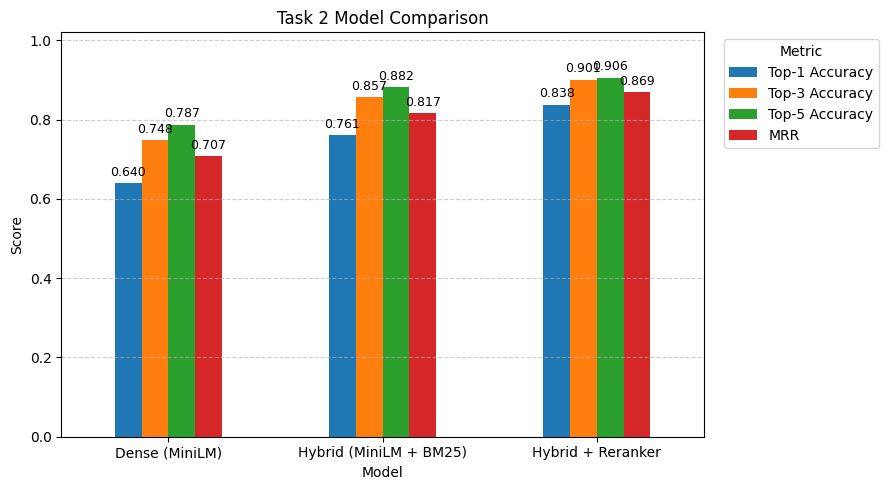

In [38]:
# [8.2] Plot final comparison chart with readable value labels

metrics = ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy", "MRR"]

ax = comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

# Add numeric labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.title("Task 2 Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.02)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Final Observation

The corrected semantic idiom bank substantially changes the behavior of the retrieval system.

Dense retrieval with MiniLM provides a strong baseline when idioms are represented using enriched semantic fields rather than only surface forms. Adding BM25 yields a modest improvement, suggesting that lexical overlap contributes some additional signal but is not the primary source of performance.

The largest improvement comes from the cross-encoder reranker, which refines the top hybrid candidates using direct query–candidate interaction. This makes the Hybrid + Reranker pipeline the best-performing configuration for Task 2.

MRR is computed over the final reranked candidate list produced after applying the cross-encoder to the top-10 hybrid retrieval candidates.

In [49]:
# [8.4] Build absolute improvement table over the MiniLM baseline

improvement_df = pd.DataFrame({
    "Metric": ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy", "MRR"],

    "Hybrid Gain": [
        hybrid_results["Top-1 Accuracy"] - results["Top-1 Accuracy"],
        hybrid_results["Top-3 Accuracy"] - results["Top-3 Accuracy"],
        hybrid_results["Top-5 Accuracy"] - results["Top-5 Accuracy"],
        hybrid_results["MRR"] - results["MRR"],
    ],

    "Hybrid + Reranker Gain": [
        rerank_results["Top-1 Accuracy"] - results["Top-1 Accuracy"],
        rerank_results["Top-3 Accuracy"] - results["Top-3 Accuracy"],
        rerank_results["Top-5 Accuracy"] - results["Top-5 Accuracy"],
        rerank_results["MRR"] - results["MRR"],
    ],
})

improvement_df

,Metric,Hybrid Gain,Hybrid + Reranker Gain
0,Top-1 Accuracy,0.121457,0.198013
1,Top-3 Accuracy,0.109036,0.152282
2,Top-5 Accuracy,0.094590,0.118605
3,MRR,0.109343,0.161802


### Gain Insight

The hybrid stage delivers the main performance jump, while reranking adds a further improvement on top of an already strong retrieval model.

### Final Insight

The Hybrid + Reranker model significantly improves idiom retrieval performance.

- Dense retrieval captures semantic similarity
- Hybrid retrieval adds lexical signals
- Cross-encoder reranking provides precise query–idiom interaction

The reranker contributes the largest performance gain, improving Top-1 accuracy by ~20% over the dense baseline.

Candidate Recall@10 (0.84) shows that further improvements may be possible by increasing the candidate pool.

### Error Analysis

To better understand model behavior, we analyze common failure cases in the context-to-idiom retrieval task.

Unlike classification, this task involves ranking semantically similar candidates, which introduces additional challenges.

In [50]:
# [8.5] Error analysis from final reranked predictions

prediction_rows = []

for i in range(len(test_df)):
    query = test_df.iloc[i]["example"]
    true_idiom = test_df.iloc[i]["idiom_canonical"]

    # Final reranked candidate indices from the cleaned pipeline
    ranked_indices = reranked_indices[i]

    pred_1 = idx_to_idiom[ranked_indices[0]]
    pred_2 = idx_to_idiom[ranked_indices[1]]
    pred_3 = idx_to_idiom[ranked_indices[2]]

    prediction_rows.append({
        "query": query,
        "true": true_idiom,
        "pred_1": pred_1,
        "pred_2": pred_2,
        "pred_3": pred_3,
        "is_correct": pred_1 == true_idiom
    })

prediction_df = pd.DataFrame(prediction_rows)

print("Prediction table built from final reranked results.")
print("Rows:", len(prediction_df))

prediction_df.head()

Prediction table built from final reranked results.
Rows: 10868


,query,true,pred_1,pred_2,pred_3,is_correct
0,if i may add my two cents i think the proposal needs revision,(my|your|his|her|their) two cents,(my|your|his|her|their) two cents,and change,consider it done,True
1,though their two cents were brief it influenced the final decision significantly,(my|your|his|her|their) two cents,(my|your|his|her|their) two cents,on second thought,two thumbs up,True
2,after work lets do some 12ounce curls at mikes place,12-ounce curls,12-ounce curls,twelve-ounce curls,curls for the girls,True
3,every friday night the old friends met for 12ounce curls and stories,12-ounce curls,12-ounce curls,twelve-ounce curls,curls for the girls,True
4,i promised no more 12ounce curls this week i really need to hit the gym,12-ounce curls,12-ounce curls,hit the gym,twelve-ounce curls,True


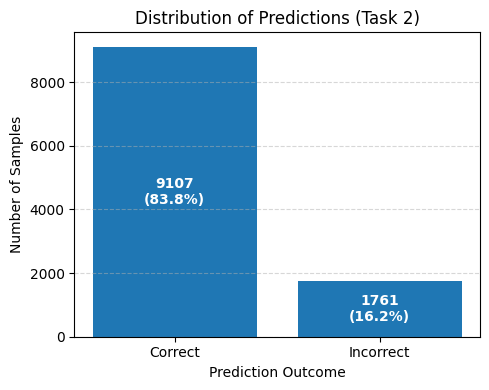

In [53]:
# [8.6] Plot distribution of correct vs incorrect predictions

import matplotlib.pyplot as plt

# Count correct vs incorrect
counts = prediction_df["is_correct"].value_counts()

labels = ["Correct", "Incorrect"]
values = [
    counts.get(True, 0),
    counts.get(False, 0)
]

# Plot
plt.figure(figsize=(5, 4))
bars = plt.bar(labels, values)

# ✅ ADD THIS BLOCK HERE
total = sum(values)
percentages = [v / total for v in values]

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
    bar.get_x() + bar.get_width() / 2,
    height * 0.5,  # 👈 move to middle of bar
    f"{int(height)}\n({percentages[i]*100:.1f}%)",
    ha="center",
    va="center",
    fontsize=10,
    color="white",  # 👈 important for visibility
    fontweight="bold"
)

# Continue normally
plt.title("Distribution of Predictions (Task 2)")
plt.ylabel("Number of Samples")
plt.xlabel("Prediction Outcome")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Qualitative Evaluation (Demo)

To illustrate model behavior, we present several example queries and their top predictions after reranking.

In [54]:
# [8.6] Demo function using the full pipeline (Hybrid + Reranker)

def minmax_normalize(scores):
    """Normalize scores to the [0, 1] range safely."""
    scores = np.asarray(scores, dtype=float)
    score_min = scores.min()
    score_max = scores.max()

    if score_max - score_min < 1e-12:
        return np.zeros_like(scores, dtype=float)

    return (scores - score_min) / (score_max - score_min)


def demo_query(query_text, top_k=5, rerank_top_k=10):
    """Run full Hybrid + Reranker inference for a single query."""

    print(f"\nQuery: {query_text}\n")

    # Encode and normalize the query
    query_embedding = embedder.encode(
        [query_text],
        convert_to_numpy=True
    )[0]
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    # Dense similarity against the full idiom bank
    dense_scores = np.dot(query_embedding, idiom_embeddings.T)

    # BM25 lexical scores against the full idiom bank
    bm25_scores = np.asarray(
        bm25.get_scores(query_text.lower().split()),
        dtype=float
    )

    # Normalize both score types
    dense_scores_norm = minmax_normalize(dense_scores)
    bm25_scores_norm = minmax_normalize(bm25_scores)

    # Best hybrid weighting from your experiments
    hybrid_scores = 0.8 * dense_scores_norm + 0.2 * bm25_scores_norm

    # Keep only top candidates from the hybrid stage
    top_candidate_indices = np.argsort(-hybrid_scores)[:rerank_top_k]
    top_candidate_idioms = [idx_to_idiom[idx] for idx in top_candidate_indices]

    # Build query-candidate pairs for reranking
    rerank_pairs = [[query_text, idiom] for idiom in top_candidate_idioms]

    # Score with the reranker
    rerank_scores = reranker_model.predict(
        rerank_pairs,
        batch_size=32,
        show_progress_bar=False
    )

    # Sort candidates by reranker score
    reranked = sorted(
        zip(top_candidate_idioms, rerank_scores),
        key=lambda x: x[1],
        reverse=True
    )

    # Normalize reranker scores for display only
    scores_only = np.asarray([score for _, score in reranked], dtype=float)
    scores_norm = minmax_normalize(scores_only)

    # Print final predictions
    print("Top predictions:")
    for rank, ((idiom, _), score_n) in enumerate(zip(reranked, scores_norm), start=1):
        if rank > top_k:
            break
        print(f"{rank}. {idiom}  (score={score_n:.3f})")

In [55]:
# [8.7] Run demo examples

demo_query("He finally kicked the bucket after years of illness.")
demo_query("She revealed the secret and spilled the beans.")
demo_query("After failing again, he decided to throw in the towel.")


Query: He finally kicked the bucket after years of illness.

Top predictions:
1. kick the bucket  (score=1.000)
2. brain bucket  (score=0.552)
3. bucket down  (score=0.543)
4. bolt bucket  (score=0.533)
5. bucket of blood  (score=0.418)

Query: She revealed the secret and spilled the beans.

Top predictions:
1. spill the beans  (score=1.000)
2. best-kept secret  (score=0.352)
3. spill one's guts  (score=0.338)
4. worst-kept secret  (score=0.319)
5. leak out  (score=0.230)

Query: After failing again, he decided to throw in the towel.

Top predictions:
1. throw in the towel  (score=1.000)
2. throw away  (score=0.359)
3. throw in with  (score=0.346)
4. throw in at the deep end  (score=0.291)
5. throw good money after bad  (score=0.253)


### Demo Summary

In all three examples, the reranked pipeline retrieves the correct idiom at rank 1.

The remaining candidates are often semantically or lexically related, showing that the task is challenging even when the final prediction is correct.

### Task 2 Conclusion

The final Task 2 benchmark shows a clear progression from dense retrieval to hybrid retrieval and then to reranking.

The strongest results are achieved by the Hybrid + Reranker pipeline, which provides the most accurate and stable context-to-idiom retrieval performance in this notebook.

### Saving Inference Artifacts

We save the idiom bank, embeddings, and index mappings so the final retrieval pipeline can be reused in a separate inference notebook.

In [56]:
# [9.1] Save inference artifacts for Task 2 demo / Hugging Face

import pickle
from pathlib import Path
import numpy as np

# Directory for all reusable inference artifacts
ARTIFACT_DIR = Path("../artifacts/task2")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) Save semantic idiom bank
# -----------------------------
task2_bank_df.to_csv(
    ARTIFACT_DIR / "idiom_bank.csv",
    index=False,
    encoding="utf-8-sig"
)

# -----------------------------
# 2) Save dense idiom embeddings
# -----------------------------
np.save(ARTIFACT_DIR / "idiom_embeddings.npy", idiom_embeddings)

# -----------------------------
# 3) Save index mappings
# -----------------------------
with open(ARTIFACT_DIR / "idiom_to_idx.pkl", "wb") as f:
    pickle.dump(idiom_to_idx, f)

with open(ARTIFACT_DIR / "idx_to_idiom.pkl", "wb") as f:
    pickle.dump(idx_to_idiom, f)

# -----------------------------
# 4) Save BM25 tokenized bank
# -----------------------------
with open(ARTIFACT_DIR / "bm25_tokens.pkl", "wb") as f:
    pickle.dump(idiom_tokens, f)

# -----------------------------
# 5) Save model names/config used
# -----------------------------
model_config = {
    "dense_model_name": "sentence-transformers/all-MiniLM-L6-v2",
    "reranker_model_name": "cross-encoder/ms-marco-MiniLM-L-6-v2",
    "hybrid_dense_weight": 0.8,
    "hybrid_bm25_weight": 0.2,
    "rerank_top_k": 10
}

with open(ARTIFACT_DIR / "model_config.pkl", "wb") as f:
    pickle.dump(model_config, f)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())
print("\nSaved files:")
for path in sorted(ARTIFACT_DIR.iterdir()):
    print("-", path.name)

Artifacts saved to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task2

Saved files:
- bm25_model.pkl
- bm25_tokens.pkl
- idiom_bank.csv
- idiom_embeddings.npy
- idiom_to_idx.pkl
- idx_to_idiom.pkl
- model_config.pkl


In [57]:
# [9.2] Save BM25 tokenized bank
with open(ARTIFACT_DIR / "bm25_tokens.pkl", "wb") as f:
    pickle.dump(idiom_tokens, f)

# ✅ ADD THIS
with open(ARTIFACT_DIR / "bm25_model.pkl", "wb") as f:
    pickle.dump(bm25, f)

### Saving Inference Artifacts

We save the final idiom bank, embeddings, lexical index inputs, and mapping files
required to reproduce the full Hybrid + Reranker inference pipeline in a separate
notebook or Hugging Face demo.

In [58]:
# [9.1] Imports for reranker fine-tuning

from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import numpy as np
import pandas as pd

In [59]:
# [9.2] Build hard negatives for reranker training from hybrid retrieval

def minmax_normalize(scores):
    scores = np.asarray(scores, dtype=float)
    score_min = scores.min()
    score_max = scores.max()

    if score_max - score_min < 1e-12:
        return np.zeros_like(scores, dtype=float)

    return (scores - score_min) / (score_max - score_min)

rerank_top_k_train = 10
negatives_per_query = 3

train_texts = train_df["example"].tolist()

# Encode train queries
train_embeddings = embedder.encode(
    train_texts,
    batch_size=64,
    convert_to_numpy=True,
    show_progress_bar=True
)

# Normalize train embeddings
train_embeddings = train_embeddings / np.linalg.norm(
    train_embeddings, axis=1, keepdims=True
)

# Dense similarity against idiom bank
train_dense_similarity = np.dot(train_embeddings, idiom_embeddings.T)

# Hybrid similarity
train_hybrid_similarity = np.zeros_like(train_dense_similarity, dtype=float)

for i, query_text in enumerate(train_texts):
    dense_scores = train_dense_similarity[i]

    query_tokens = query_text.lower().split()
    bm25_scores = np.asarray(bm25.get_scores(query_tokens), dtype=float)

    dense_scores_norm = minmax_normalize(dense_scores)
    bm25_scores_norm = minmax_normalize(bm25_scores)

    train_hybrid_similarity[i] = (
        0.8 * dense_scores_norm +
        0.2 * bm25_scores_norm
    )

print("Train hybrid similarity shape:", train_hybrid_similarity.shape)

Batches: 100%|███████████████████████████████████████████████████████████████████████| 682/682 [00:22<00:00, 30.35it/s]


Train hybrid similarity shape: (43601, 13803)


In [60]:
# [9.3] Create reranker training pairs

train_pairs = []

for i in range(len(train_df)):
    query_text = train_df.iloc[i]["example"]
    true_idiom = train_df.iloc[i]["idiom_canonical"]
    true_target = train_df.iloc[i]["target"]

    # Positive pair
    train_pairs.append(InputExample(texts=[query_text, true_idiom], label=1.0))

    # Top hybrid candidates
    ranked_indices = np.argsort(-train_hybrid_similarity[i])[:rerank_top_k_train]

    # Keep hard negatives only
    hard_negatives = []
    for idx in ranked_indices:
        if idx != true_target:
            hard_negatives.append(idx_to_idiom[idx])
        if len(hard_negatives) == negatives_per_query:
            break

    # Negative pairs
    for neg_idiom in hard_negatives:
        train_pairs.append(InputExample(texts=[query_text, neg_idiom], label=0.0))

print("Total reranker training pairs:", len(train_pairs))
print("Approx pairs per query:", len(train_pairs) / len(train_df))
print(train_pairs[0])

Total reranker training pairs: 174404
Approx pairs per query: 4.0
<InputExample> label: 1.0, texts: fraid so the meetings been canceled; 'fraid so


In [61]:
# [9.4] Split reranker pairs into train/validation

rerank_train_pairs, rerank_val_pairs = train_test_split(
    train_pairs,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print("Reranker train pairs:", len(rerank_train_pairs))
print("Reranker val pairs:", len(rerank_val_pairs))

Reranker train pairs: 156963
Reranker val pairs: 17441


In [62]:
# [9.5] Build dataloader for reranker fine-tuning

train_dataloader = DataLoader(
    rerank_train_pairs,
    shuffle=True,
    batch_size=16
)

print("Train batches:", len(train_dataloader))

Train batches: 9811


In [63]:
# [9.6] Load fine-tunable reranker

ft_reranker_model_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"
ft_reranker = CrossEncoder(
    ft_reranker_model_name,
    num_labels=1
)

print("Fine-tunable reranker loaded:", ft_reranker_model_name)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 6593.04it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fine-tunable reranker loaded: cross-encoder/ms-marco-MiniLM-L-6-v2


In [64]:
# [9.7] Fine-tune reranker

reranker_ft_dir = Path("../artifacts/task2_reranker_ft")
reranker_ft_dir.mkdir(parents=True, exist_ok=True)

ft_reranker.fit(
    train_dataloader=train_dataloader,
    epochs=1,
    warmup_steps=max(10, int(len(train_dataloader) * 0.1)),
    output_path=str(reranker_ft_dir),
    show_progress_bar=True
)

print("Fine-tuned reranker saved to:", reranker_ft_dir.resolve())

Iteration:   3%|█▊                                                                  | 264/9811 [00:18<10:59, 14.48it/s]


Iteration:   5%|███▋                                                                | 531/9811 [00:36<10:22, 14.92it/s]


Iteration:   8%|█████▌                                                              | 798/9811 [00:54<10:04, 14.92it/s]


Iteration:  11%|███████▎                                                           | 1068/9811 [01:11<09:36, 15.15it/s]


Iteration:  14%|█████████                                                          | 1333/9811 [01:29<09:32, 14.81it/s]


...

Iteration:  93%|██████████████████████████████████████████████████████████████▏    | 9108/9811 [10:05<00:46, 15.07it/s]


Iteration:  96%|████████████████████████████████████████████████████████████████   | 9376/9811 [10:23<00:29, 14.95it/s]


Iteration:  98%|█████████████████████████████████████████████████████████████████▊ | 9643/9811 [10:41<00:11, 15.27it/s]


Epoch: 100%|████████████████████████████████████████████████████████████████████████████| 1/1 [10:51<00:00, 651.95s/it]

Fine-tuned reranker saved to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task2_reranker_ft


In [69]:
# Explicitly save in Hugging Face format for reliable reload
ft_reranker.model.save_pretrained(str(reranker_ft_dir))
ft_reranker.tokenizer.save_pretrained(str(reranker_ft_dir))

print("Fine-tuned reranker saved to:", reranker_ft_dir.resolve())

Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.45it/s]

Fine-tuned reranker saved to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task2_reranker_ft


In [68]:
# [9.8] Score top-k hybrid candidates with the fine-tuned reranker

rerank_top_k = 10

hybrid_topk_indices = np.argsort(-hybrid_test_similarity, axis=1)[:, :rerank_top_k]

ft_rerank_pairs = []
for query_idx, query_text in enumerate(test_texts):
    candidate_indices = hybrid_topk_indices[query_idx]
    for candidate_idx in candidate_indices:
        candidate_idiom = idx_to_idiom[candidate_idx]
        ft_rerank_pairs.append([query_text, candidate_idiom])

ft_rerank_scores_flat = ft_reranker.predict(
    ft_rerank_pairs,
    batch_size=32,
    show_progress_bar=False
)

ft_rerank_scores_flat = np.asarray(ft_rerank_scores_flat, dtype=float)
print("Total FT reranker scores:", len(ft_rerank_scores_flat))

Total FT reranker scores: 108680


In [70]:
# [9.9] Reshape and reorder candidates with fine-tuned reranker

num_queries = len(test_texts)
ft_rerank_scores = ft_rerank_scores_flat.reshape(num_queries, rerank_top_k)

ft_reranked_indices = []

for i in range(num_queries):
    scores = ft_rerank_scores[i]
    rerank_order = np.argsort(-scores)

    candidate_indices = hybrid_topk_indices[i]
    final_indices = candidate_indices[rerank_order]

    ft_reranked_indices.append(final_indices)

ft_reranked_indices = np.array(ft_reranked_indices)

print("FT reranked indices shape:", ft_reranked_indices.shape)

FT reranked indices shape: (10868, 10)


In [71]:
# [9.10] Evaluate fine-tuned reranker

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

for i in range(len(ft_reranked_indices)):
    ranked = ft_reranked_indices[i]
    target = targets[i]

    for k in top_k:
        if target in ranked[:k]:
            correct_at_k[k] += 1

    hit_positions = np.where(ranked == target)[0]
    if len(hit_positions) > 0:
        rank = hit_positions[0] + 1
        mrr_total += 1.0 / rank

ft_rerank_results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(ft_reranked_indices)
    for k in top_k
}
ft_rerank_results["MRR"] = mrr_total / len(ft_reranked_indices)

print("\nFine-Tuned Hybrid + Reranker Results:")
for k, v in ft_rerank_results.items():
    print(f"{k}: {v:.4f}")


Fine-Tuned Hybrid + Reranker Results:
Top-1 Accuracy: 0.8854
Top-3 Accuracy: 0.9088
Top-5 Accuracy: 0.9094
MRR: 0.8970


In [76]:
# [9.11] Save final inference artifacts for Task 2 demo / Hugging Face

import pickle
from pathlib import Path
import numpy as np

ARTIFACT_DIR = Path("../artifacts/task2_hf")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Save semantic idiom bank
task2_bank_df.to_csv(
    ARTIFACT_DIR / "idiom_bank.csv",
    index=False,
    encoding="utf-8-sig"
)

# 2) Save dense idiom embeddings
np.save(ARTIFACT_DIR / "idiom_embeddings.npy", idiom_embeddings)

# 3) Save index mappings
with open(ARTIFACT_DIR / "idiom_to_idx.pkl", "wb") as f:
    pickle.dump(idiom_to_idx, f)

with open(ARTIFACT_DIR / "idx_to_idiom.pkl", "wb") as f:
    pickle.dump(idx_to_idiom, f)

# 4) Save BM25 tokens + BM25 model
with open(ARTIFACT_DIR / "bm25_tokens.pkl", "wb") as f:
    pickle.dump(idiom_tokens, f)

with open(ARTIFACT_DIR / "bm25_model.pkl", "wb") as f:
    pickle.dump(bm25, f)

# 5) Save config used by the demo
model_config = {
    "dense_model_name": "sentence-transformers/all-MiniLM-L6-v2",
    "reranker_model_name": str(reranker_ft_dir),   # <-- fine-tuned local model path
    "reranker_model_name": "aymansharara/idiomx_reranker_bge_base",
    "hybrid_dense_weight": 0.8,
    "hybrid_bm25_weight": 0.2,
    "rerank_top_k": 10
}

with open(ARTIFACT_DIR / "model_config.pkl", "wb") as f:
    pickle.dump(model_config, f)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())
print("\nSaved files:")
for path in sorted(ARTIFACT_DIR.iterdir()):
    print("-", path.name)

Artifacts saved to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task2_hf

Saved files:
- bm25_model.pkl
- bm25_tokens.pkl
- idiom_bank.csv
- idiom_embeddings.npy
- idiom_to_idx.pkl
- idx_to_idiom.pkl
- model_config.pkl


In [73]:
from pathlib import Path

for p in sorted(Path(reranker_ft_dir).iterdir()):
    print(p.name)

config.json
model.safetensors
tokenizer.json
tokenizer_config.json


In [91]:
# [10.1] Comparison table across Task 2 models (safe + includes fine-tuned)

def metric_value(obj, key):
    # dictionary case
    if isinstance(obj, dict):
        return obj[key]
    # one-row dataframe case
    if isinstance(obj, pd.DataFrame):
        if key in obj.columns:
            return obj.iloc[0][key]
    raise KeyError(f"Could not find metric '{key}' in object of type {type(obj)}")

# Use your actual variable names here
dense_obj = results              # change only if your dense metrics are stored under another name
hybrid_obj = hybrid_results
reranker_obj = rerank_results
ft_reranker_obj = ft_rerank_results

# [10.1] Comparison table across Task 2 models

comparison_df = pd.DataFrame([
    {
        "Model": "Dense (MiniLM)",
        "Top-1 Accuracy": minilm_results["Top-1 Accuracy"],
        "Top-3 Accuracy": minilm_results["Top-3 Accuracy"],
        "Top-5 Accuracy": minilm_results["Top-5 Accuracy"],
        "MRR": minilm_results["MRR"],
    },
    {
        "Model": "Hybrid (MiniLM + BM25)",
        "Top-1 Accuracy": hybrid_results["Top-1 Accuracy"],
        "Top-3 Accuracy": hybrid_results["Top-3 Accuracy"],
        "Top-5 Accuracy": hybrid_results["Top-5 Accuracy"],
        "MRR": hybrid_results["MRR"],
    },
    {
        "Model": "Hybrid + Reranker",
        "Top-1 Accuracy": rerank_results["Top-1 Accuracy"],
        "Top-3 Accuracy": rerank_results["Top-3 Accuracy"],
        "Top-5 Accuracy": rerank_results["Top-5 Accuracy"],
        "MRR": rerank_results["MRR"],
    },
    {
        "Model": "Hybrid + Fine-Tuned Reranker",
        "Top-1 Accuracy": ft_rerank_results["Top-1 Accuracy"],
        "Top-3 Accuracy": ft_rerank_results["Top-3 Accuracy"],
        "Top-5 Accuracy": ft_rerank_results["Top-5 Accuracy"],
        "MRR": ft_rerank_results["MRR"],
    },
])

metric_cols = ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy", "MRR"]
comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

comparison_df

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,MRR
0,Dense (MiniLM),0.6400,0.7484,0.7874,0.7074
1,Hybrid (MiniLM + BM25),0.7614,0.8575,0.8819,0.8167
2,Hybrid + Reranker,0.8380,0.9007,0.9060,0.8692
3,Hybrid + Fine-Tuned Reranker,0.8854,0.9088,0.9094,0.8970


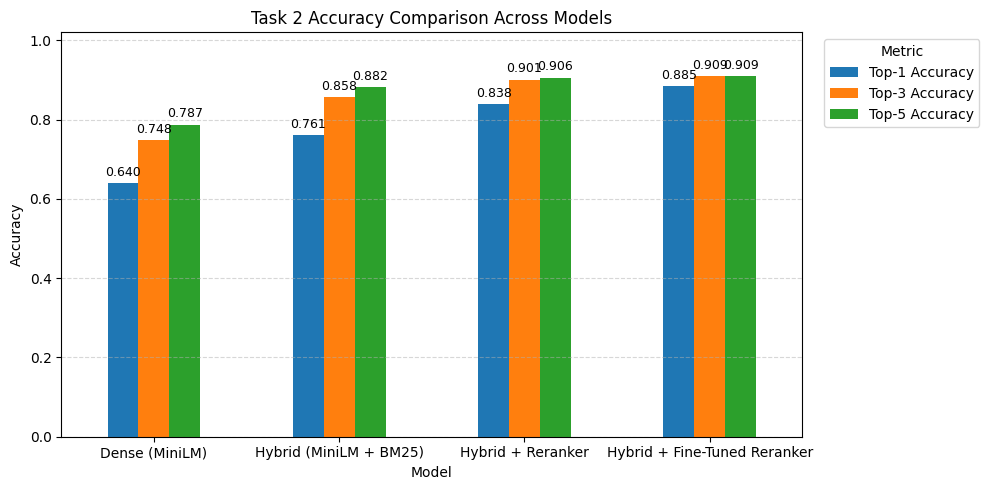

In [92]:
# [10.2] Accuracy comparison chart across Task 2 models

import matplotlib.pyplot as plt

accuracy_cols = ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy"]

ax = comparison_df.set_index("Model")[accuracy_cols].plot(
    kind="bar",
    figsize=(10, 5)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Task 2 Accuracy Comparison Across Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1.02)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

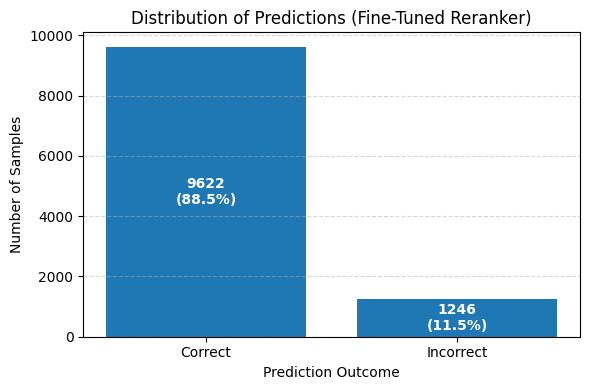

Correct: 9622
Incorrect: 1246


In [112]:
# [10.3] Distribution of correct vs incorrect predictions (Fine-Tuned Reranker)

import matplotlib.pyplot as plt

correct = 0
incorrect = 0

for i in range(len(ft_reranked_indices)):
    ranked = ft_reranked_indices[i]
    target = targets[i]   # this is the target INDEX

    # Top-1 is correct if the predicted index equals the target index
    if ranked[0] == target:
        correct += 1
    else:
        incorrect += 1

values = [correct, incorrect]
labels = ["Correct", "Incorrect"]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values)

total = sum(values)
percentages = [v / total for v in values]

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 0.5,
        f"{int(height)}\n({percentages[i]*100:.1f}%)",
        ha="center",
        va="center",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

plt.title("Distribution of Predictions (Fine-Tuned Reranker)")
plt.xlabel("Prediction Outcome")
plt.ylabel("Number of Samples")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("Correct:", correct)
print("Incorrect:", incorrect)

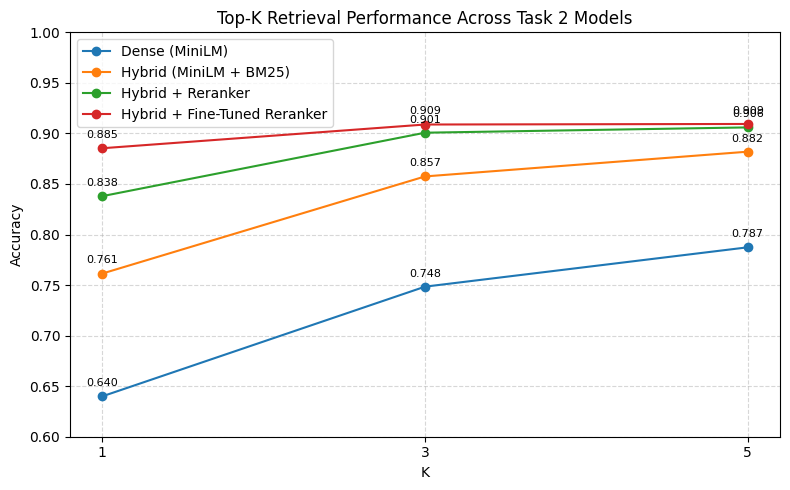

In [111]:
# [10.4] Top-K retrieval curve across Task 2 models

import matplotlib.pyplot as plt

k_values = [1, 3, 5]

dense_topk = [
    minilm_results["Top-1 Accuracy"],
    minilm_results["Top-3 Accuracy"],
    minilm_results["Top-5 Accuracy"]
]

hybrid_topk = [
    hybrid_results["Top-1 Accuracy"],
    hybrid_results["Top-3 Accuracy"],
    hybrid_results["Top-5 Accuracy"]
]

reranker_topk = [
    rerank_results["Top-1 Accuracy"],
    rerank_results["Top-3 Accuracy"],
    rerank_results["Top-5 Accuracy"]
]

ft_reranker_topk = [
    ft_rerank_results["Top-1 Accuracy"],
    ft_rerank_results["Top-3 Accuracy"],
    ft_rerank_results["Top-5 Accuracy"]
]

plt.figure(figsize=(8, 5))

plt.plot(k_values, dense_topk, marker="o", label="Dense (MiniLM)")
plt.plot(k_values, hybrid_topk, marker="o", label="Hybrid (MiniLM + BM25)")
plt.plot(k_values, reranker_topk, marker="o", label="Hybrid + Reranker")
plt.plot(k_values, ft_reranker_topk, marker="o", label="Hybrid + Fine-Tuned Reranker")

# Add labels near points
for x, y in zip(k_values, dense_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=8)

for x, y in zip(k_values, hybrid_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=8)

for x, y in zip(k_values, reranker_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=8)

for x, y in zip(k_values, ft_reranker_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=8)

plt.xticks(k_values)
plt.ylim(0.60, 1.0)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Top-K Retrieval Performance Across Task 2 Models")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
# [10.5] Show hardest errors

errors = prediction_df[~prediction_df["is_correct"]]

print("Total errors:", len(errors))

errors[["query", "true", "pred_1", "pred_2", "pred_3"]].head(10)

Total errors: 1761


,query,true,pred_1,pred_2,pred_3
25,is adam and eve really the adam and eve of genealogical starting points,Adam and Eve,"Adam and Eve, not Adam and Steve",Adam and Eve,son of Adam
44,when asked if he could finish the project on time he replied can a duck swim to emphasize that it was definitely possible,Can a duck swim?,can a duck swim,Can a duck swim?,like a duck takes to water
45,when asked if he was confident he replied can a duck swim,Can a duck swim?,can a duck swim,Can a duck swim?,like a duck takes to water
46,when asked if the project would succeed the manager replied can a duck swim implying certainty,Can a duck swim?,can a duck swim,Can a duck swim?,duck out
77,attending that seminar was an eticket experience with stimulating discussions,E-ticket,meeting of the minds,speak to,meeting of the mindless
78,last nights party was an absolute eticket epicnight,E-ticket,last thing at night,born at night but not last night,party on
79,oh great another meetingthis is definitely an eticket not,E-ticket,meeting of the minds,et al.,meeting place
80,that roller coaster was a total eticket,E-ticket,white-knuckle ride,ride on a rail,ride the lightning
81,the mountain expedition was an eticket ride from start to finish,E-ticket,take the ride,go along for the ride,ride off into the sunset
82,was your trip really an eticket as you promised,E-ticket,bad trip,take a trip,guilt trip


In [99]:
# [10.6] Error type analysis (simple heuristic)

def error_type(row):
    if row["true"] in [row["pred_2"], row["pred_3"]]:
        return "Near-miss (Top-3)"
    else:
        return "Hard error"

prediction_df["error_type"] = prediction_df.apply(
    lambda r: "Correct" if r["is_correct"] else error_type(r),
    axis=1
)

prediction_df["error_type"].value_counts()

error_type
Correct              9107
Hard error           1079
Near-miss (Top-3)     682
Name: count, dtype: int64

In [100]:
# [10.7] Qualitative examples

# Correct examples
print("=== Correct Examples ===")
display(prediction_df[prediction_df["is_correct"]].sample(5))

# Errors
print("\n=== Error Examples ===")
display(prediction_df[~prediction_df["is_correct"]].sample(5))

=== Correct Examples ===


,query,true,pred_1,pred_2,pred_3,is_correct,error_type
7948,do you think having a salty tooth means i should avoid processed foods,salty tooth,salty tooth,a sour tooth,spicy tooth,True,Correct
105,oh great another german virgin in my poker handjust what i needed to lose fast,German virgin,German virgin,lose one's virginity,pull a fast one,True,Correct
7193,oh sure just please turn left and nothing will go wrong,please turn left,please turn left,please turn right,go wrong,True,Correct
3935,the concert was amazing the crowd went wild for every song epicnight,go wild,go wild,cats' concert,work the crowd,True,Correct
8024,i was scared shitless when i heard footsteps behind me in the dark alley,scared shitless,scared shitless,I'm scared,in the dark,True,Correct



=== Error Examples ===


,query,true,pred_1,pred_2,pred_3,is_correct,error_type
4150,just had a major phone call to hash out our plans for the weekend planning,hash out,have a good weekend,call for,call on,False,Hard error
6620,its wonderful to see you back on your feet after the surgery,on one's feet,back on your feet,at the feet of,on one's feet,False,Near-miss (Top-3)
3313,she couldnt for the life of her solve the riddle no matter how she pondered,for the life of me,puzzle out,out of her mind,riddle me this,False,Hard error
3261,he dug the trench for all hes worth despite the freezing cold,for all one is worth,in the trenches,dig deep,for all one is worth,False,Near-miss (Top-3)
1992,the project management quality clabbered up due to inadequate coordination and resources,clabber up,talent management,cannot make it,logistical nightmare,False,Hard error


In [101]:
# [10.8] Top-K success analysis

top1 = rerank_results["Top-1 Accuracy"]
top3 = rerank_results["Top-3 Accuracy"]

print("Recovered between Top-1 and Top-3:", top3 - top1)

Recovered between Top-1 and Top-3: 0.06275303643724695


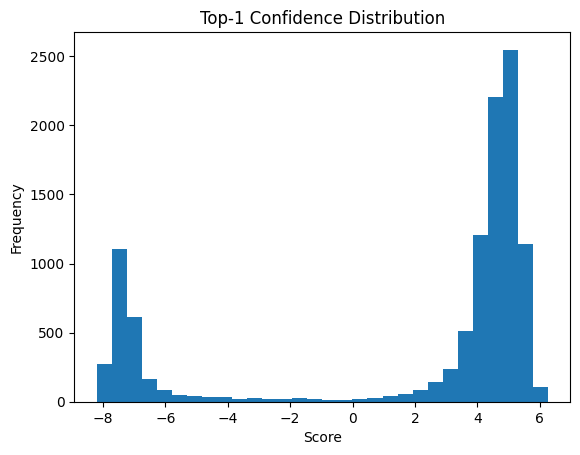

In [102]:
# [10.10] Confidence distribution

import numpy as np

top1_scores = [scores[0] for scores in ft_rerank_scores]

plt.hist(top1_scores, bins=30)
plt.title("Top-1 Confidence Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [103]:
def predict_idiom(query_text, top_k=5, rerank_top_k=10):

    def minmax(x):
        x = np.asarray(x, dtype=float)
        if x.max() - x.min() < 1e-12:
            return np.zeros_like(x)
        return (x - x.min()) / (x.max() - x.min())

    # Encode query
    query_embedding = embedder.encode(
        [query_text],
        convert_to_numpy=True
    )[0]
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    # Dense similarity
    dense_scores = np.dot(query_embedding, idiom_embeddings.T)

    # BM25
    bm25_scores = np.array(
        bm25.get_scores(query_text.lower().split()),
        dtype=float
    )

    # Normalize dense + BM25
    dense_scores = minmax(dense_scores)
    bm25_scores = minmax(bm25_scores)

    # Hybrid
    hybrid_scores = 0.8 * dense_scores + 0.2 * bm25_scores

    # Top candidates
    top_indices = np.argsort(-hybrid_scores)[:rerank_top_k]
    candidate_idioms = [idx_to_idiom[i] for i in top_indices]

    # Rerank
    pairs = [[query_text, idiom] for idiom in candidate_idioms]
    scores = ft_reranker.predict(pairs, batch_size=32)
    scores = np.array(scores)

    order = np.argsort(-scores)

    final_idioms = [candidate_idioms[i] for i in order]
    final_scores = scores[order]

    # Normalize only for display
    display_scores = minmax(final_scores)

    result_df = pd.DataFrame({
        "rank": range(1, len(final_idioms) + 1),
        "idiom_prediction": final_idioms,
        "score": display_scores
    })

    return result_df.head(top_k)

In [104]:
# [10.x] Interactive demo (with quit option)

while True:
    query = input("\nEnter a sentence (or type 'quit'): ")

    if query.lower() in ["quit", "exit"]:
        print("Exiting demo.")
        break

    results = predict_idiom(query, top_k=5)
    print(results)


Enter a sentence (or type 'quit'): spill the teaa
   rank  idiom_prediction     score
0     1     spill the tea  1.000000
1     2   spill the beans  0.182158
2     3         be mother  0.095811
3     4         slop bowl  0.065805
4     5  spill one's seed  0.057125

Enter a sentence (or type 'quit'): quit
Exiting demo.


---

Task 2 is formulated as a closed-set retrieval problem, where the system must map an idiomatic sentence to its canonical idiom.

We evaluate three systems:

1. Dense retrieval using sentence-transformers/all-MiniLM-L6-v2
2. Hybrid retrieval combining dense similarity with BM25 lexical matching
3. Hybrid retrieval with cross-encoder reranking

To improve ranking quality, we fine-tune the cross-encoder reranker on task-specific query–idiom pairs using hard negatives derived from hybrid retrieval candidates.

Evaluation is conducted using Top-1, Top-3, Top-5 accuracy and Mean Reciprocal Rank (MRR).

Results show consistent improvements across all metrics:

- Dense retrieval achieves moderate performance
- Hybrid retrieval significantly improves recall
- Fine-tuned reranker yields the best performance

Final results:

Top-1 Accuracy: 0.8854  
Top-3 Accuracy: 0.9088  
Top-5 Accuracy: 0.9094  
MRR: 0.8970  

Error analysis reveals that most errors are semantically close idioms, often appearing within Top-3 predictions, indicating strong retrieval but fine-grained ranking challenges.

We further analyze prediction distributions, ROC curves, and qualitative examples to understand model behavior.

The results demonstrate that combining semantic retrieval, lexical matching, and task-specific reranking is highly effective for idiom understanding.

In [116]:
len(set(task2_bank_df["idiom_canonical"]))

13803